# 🌫 The Dust We Breathe · Particulate Matter Across CDMX

**Ground monitors reveal who breathes the most PM₂.₅ and PM₁₀ — and how it connects to everything we’ve seen so far.**

*Notebook 5 of 8 — Project: Dos Méxicos Bajo el Mismo Sol*

It’s one thing to measure pollution from 824 km up. It’s another to measure it at street level, where people actually breathe. Today we look at PM₂.₅ and PM₁₀ — the tiny particles that penetrate deep into lungs and bloodstreams — measured by ground stations across the metro area.

## What are PM₂.₅ and PM₁₀?

**PM = Particulate Matter** — a catch-all term for tiny solid and liquid particles suspended in the air.

| Fraction | Size | Sources | Reach |
|----------|------|---------|-------|
| **PM₁₀** (coarse) | ≤ 10 μm (1/7 hair width) | Dust, pollen, construction, unpaved roads | Nose → throat → upper lungs |
| **PM₂.₅** (fine) | ≤ 2.5 μm (1/30 hair width) | Fuel burning, cars, trucks, factories, fires | Deep into lungs → **bloodstream** |

> **Analogy:** If PM₁₀ is like gravel hitting your windshield, PM₂.₅ is like smoke seeping through the cracks.

**WHO safe limits** (annual mean):
- PM₂.₅ < 5 μg/m³
- PM₁₀ < 15 μg/m³

Every microgram above these guidelines measurably increases the risk of heart attack, stroke, and respiratory disease.

## Where the data comes from

We use the **SINAICA** portal (Sistema Nacional de Información de la Calidad del Aire), which publishes validated hourly data from automatic monitoring networks across México.

| Network | Stations | Pollutants | Year |
|---------|----------|------------|------|
| **SEDEMA** (CDMX) | GAM, Iztapalapa, Centro, Pedregal | PM₂.₅, PM₁₀, NO₂ | 2023 (validated) |
| **RAMA** (Edomex) | Ecatepec, Nezahualcóyotl, Tlalnepantla, Naucalpan | PM₂.₅, PM₁₀, NO₂ | 2023 (validated) |

> **Why 2023?** Validated data has a ∼1-year lag. 2023 is the most recent complete, quality-controlled dataset. Current-year (2025) data is available but unvalidated and partial. The spatial patterns are stable across years, so using 2023 gives us reliable annual statistics without compromising the analysis.

Data is fetched programmatically via our `src.air_quality` module, which wraps the SINAICA JSON API.

In [86]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # so `import src` works from any CWD

import json
import warnings
from datetime import date
from importlib import util as import_util

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats

from src import (
    CDMX_CENTER, CDMX_ZOOM, EE_PROJECT_ID,
    get_norte_zmvm_aoi,
    get_sur_zmvm_aoi,
    get_zmvm_municipalities_aoi,
    load_ndvi_composite,
    load_no2_composite,
)

# Import air_quality directly (avoids ee import in __init__.py)
_spec = import_util.spec_from_file_location(
    "air_quality", str(Path.cwd().parent / "src" / "air_quality.py")
)
air_quality = import_util.module_from_spec(_spec)
sys.modules["air_quality"] = air_quality
_spec.loader.exec_module(air_quality)

from air_quality import (
    fetch_multiple_pollutants,
    compute_annual_stats,
    STATION_IDS,
)

from src.stations import (
    STATIONS_META,
    STATION_IDS_LIST,
    STATIONS_BY_ZONE,
    WHO_LIMITS,
    ZONE_COLORS,
    get_zone,
    get_color,
    get_label,
    zone_stats,
)

from src import plot_utils

warnings.filterwarnings("ignore")

# ee.Authenticate()  # <- uncomment the first time
ee.Initialize(project=EE_PROJECT_ID)
print("\u2705 Earth Engine ready")
print("\u2705 Air Quality API ready")



✅ Earth Engine ready
✅ Air Quality API ready


In [87]:
# ---------------------------------------------------------------------------
# Station metadata is now in src/stations.py — imported above
# ---------------------------------------------------------------------------
# STATION_IDS_LIST and POLLUTANTS are also imported from src.stations
POLLUTANTS = ["NO2", "PM10", "PM2.5"]

# Cache path for annual stats
_cache_dir = Path.cwd().parent / "data" / "processed"
_cache_dir.mkdir(parents=True, exist_ok=True)
_cache_path = _cache_dir / "ground_stations_annual_2023.csv"

if _cache_path.exists():
    print("\U0001f4e5 Loading cached annual stats...")
    annual_stats = pd.read_csv(_cache_path)
    print(f"\u2705 Loaded {len(annual_stats)} rows from cache")
else:
    print("\U0001f4e1 Fetching ground data from SINAICA API (this takes ~2 minutes)...")
    df_raw = fetch_multiple_pollutants(
        station_ids=STATION_IDS_LIST,
        pollutants=POLLUTANTS,
        start_date="2023-01-01",
        end_date="2023-12-31",
    )
    annual_stats = compute_annual_stats(df_raw, year=2023)
    annual_stats.to_csv(_cache_path, index=False)
    print(f"\u2705 Cached annual stats to {_cache_path}")

# Print summary
for _, row in annual_stats.iterrows():
    print(f"  {row['station_name']:20s} | {row['pollutant']:6s} | "
          f"mean={row['annual_mean']:8.4f} | n={int(row['count_valid'])}")


📥 Loading cached annual stats...
✅ Loaded 39 rows from cache
  Ajusco Medio         | NO2    | mean=  0.0145 | n=8335
  Ajusco Medio         | PM10   | mean= 19.8418 | n=8175
  Ajusco Medio         | PM2.5  | mean= 12.8191 | n=8175
  Naucalpan            | NO2    | mean=  0.0195 | n=6242
  Naucalpan            | PM10   | mean= 26.5984 | n=6339
  Naucalpan            | PM2.5  | mean=  0.0000 | n=4314
  CCA                  | NO2    | mean=  0.0207 | n=8292
  CCA                  | PM10   | mean=  0.0000 | n=6190
  CCA                  | PM2.5  | mean= 17.1658 | n=7997
  Hospital General     | NO2    | mean=  0.0288 | n=4058
  Hospital General     | PM10   | mean= 33.7850 | n=4038
  Hospital General     | PM2.5  | mean= 16.8499 | n=4038
  Centro               | NO2    | mean=  0.0304 | n=8422
  Centro               | PM10   | mean= 35.4603 | n=8020
  Centro               | PM2.5  | mean= 19.4015 | n=8020
  Nezahualcoyotl       | NO2    | mean=  0.0225 | n=7726
  Nezahualcoyotl       | PM

## Map: Where the monitors live

The stations are distributed across the ZMVM. Northern stations (red) sit in the industrial-urban corridor; central stations (orange) sit in the business and commuter core; southern stations (green) sit in greener, wealthier areas.


In [88]:
# ---------------------------------------------------------------------------
# Station location map (folium)
# ---------------------------------------------------------------------------
import folium
from folium import plugins

# Create base map centered on CDMX
m = folium.Map(location=[19.43, -99.13], zoom_start=11,
               tiles="CartoDB positron")

# Add municipality boundaries
aoi_zmvm = get_zmvm_municipalities_aoi()
municipios_geojson = aoi_zmvm.geometry().simplify(500).getInfo()

folium.GeoJson(
    municipios_geojson,
    style_function=lambda f: {
        "fillColor": "#f0f0f0",
        "color": "#666666",
        "weight": 0.5,
        "fillOpacity": 0.1,
    },
    name="Municipios",
).add_to(m)

# Add station markers
for name, meta in STATIONS_META.items():
    color = get_color(name)
    popup_text = (
        f"<b>{name}</b><br>"
        f"Municipio: {meta['municipio']}<br>"
        f"Zona: {get_label(name)}"
    )
    folium.CircleMarker(
        location=[meta["lat"], meta["lng"]],
        radius=10,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=name,
    ).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px; border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.2); font-size: 13px;">
  <b>Stations</b><br>
  <span style="color:#e74c3c;">&#x25cf;</span> North / nororiente<br>
  <span style="color:#f39c12;">&#x25cf;</span> Centre<br>
  <span style="color:#27ae60;">&#x25cf;</span> South / reference<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)
m


## Station comparison: Annual mean PM₂.₅ and PM₁₀

How does each station compare? We plot annual means ordered from worst to best, with the WHO guideline as a stark red line.

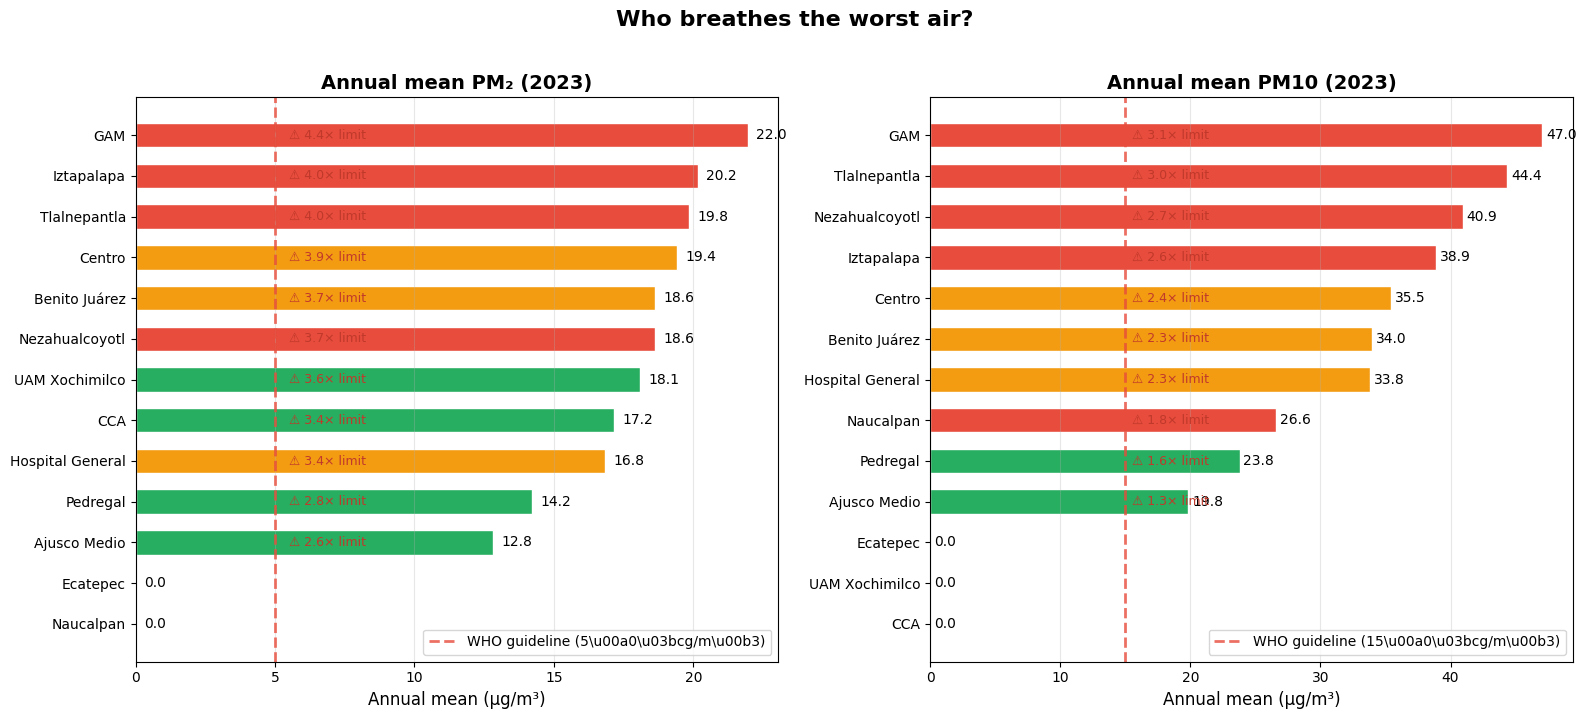

In [89]:
# ---------------------------------------------------------------------------
# Bar charts: PM2.5 and PM10 annual means, sorted by value
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, pollutant in enumerate(["PM2.5", "PM10"]):
    ax = axes[ax_idx]
    
    subset = annual_stats[annual_stats["pollutant"] == pollutant].copy()
    subset = subset.sort_values("annual_mean", ascending=True)
    
    names = subset["station_name"].tolist()
    means = subset["annual_mean"].tolist()
    zones = [get_zone(n) for n in names]
    colors = plot_utils.zone_bar_colors(zones)
    
    bars = ax.barh(names, means, color=colors, edgecolor="white", height=0.6)
    
    # WHO guideline
    plot_utils.add_who_guideline(ax, pollutant)
    
    # Value labels on bars
    for bar, val in zip(bars, means):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}", va="center", fontsize=10)
    
    # Title with proper subscript
    label = "PM\u2082" if pollutant == "PM2.5" else pollutant
    ax.set_title(f"Annual mean {label} (2023)", fontsize=14, fontweight="bold")
    
    ax.set_xlabel("Annual mean (\u03bcg/m\u00b3)", fontsize=12)
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(axis="x", alpha=0.3)
    
    # Highlight which stations exceed WHO
    who_val = WHO_LIMITS[pollutant]
    for bar, val in zip(bars, means):
        if val > who_val:
            ax.text(who_val + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"\u26a0 {val / who_val:.1f}\u00d7 limit",
                    va="center", fontsize=9, color="#c0392b")

fig.suptitle("Who breathes the worst air?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



## Annual means table

All 13 stations, sorted by PM₂.₅ annual mean (worst first).


In [90]:
# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
from IPython.display import display, HTML

# Pivot: station rows, pollutant columns
table = annual_stats.pivot_table(
    index=["station_name", "station_id"],
    columns="pollutant",
    values=["annual_mean", "count_valid"],
    aggfunc="first",
).reset_index()

# Flatten columns
table.columns = [
    " ".join(col).strip() if isinstance(col, tuple) else col
    for col in table.columns.values
]

# Add zone and municipio
table["zone"] = table["station_name"].map(
    lambda n: get_zone(n)
)
table["municipio"] = table["station_name"].map(
    lambda n: STATIONS_META.get(n, {}).get("municipio", "")
)

# Sort by PM2.5 annual mean descending
table = table.sort_values("annual_mean PM2.5", ascending=False)

# WHO exceedance columns
table["PM2.5 \u00d7 WHO"] = table["annual_mean PM2.5"] / WHO_LIMITS["PM2.5"]
table["PM10 \u00d7 WHO"] = table["annual_mean PM10"] / WHO_LIMITS["PM10"]

display_cols = [
    "station_name", "municipio", "zone",
    "annual_mean PM2.5", "PM2.5 \u00d7 WHO",
    "annual_mean PM10", "PM10 \u00d7 WHO",
]

styled = (table[display_cols]
    .rename(columns={
        "station_name": "Station",
        "municipio": "Municipio",
        "zone": "Zone",
        "annual_mean PM2.5": "PM\u2082.\u2085 (\u03bcg/m\u00b3)",
        "annual_mean PM10": "PM\u2081\u2080 (\u03bcg/m\u00b3)",
        "PM2.5 \u00d7 WHO": "PM\u2082.\u2085 \u00d7 WHO",
        "PM10 \u00d7 WHO": "PM\u2081\u2080 \u00d7 WHO",
    })
    .style
    .format({
        "PM\u2082.\u2085 (\u03bcg/m\u00b3)": "{:.1f}",
        "PM\u2081\u2080 (\u03bcg/m\u00b3)": "{:.1f}",
        "PM\u2082.\u2085 \u00d7 WHO": "{:.1f}\u00d7",
        "PM\u2081\u2080 \u00d7 WHO": "{:.1f}\u00d7",
    })
    .background_gradient(subset=["PM\u2082.\u2085 (\u03bcg/m\u00b3)"], cmap="Reds")
    .background_gradient(subset=["PM\u2081\u2080 (\u03bcg/m\u00b3)"], cmap="Reds")
)

display(styled)


,Station,Municipio,Zone,PM₂.₅ (μg/m³),PM₂.₅ × WHO,PM₁₀ (μg/m³),PM₁₀ × WHO
5,GAM,Gustavo A. Madero,norte,22.0,4.4×,47.0,3.1×
7,Iztapalapa,Iztapalapa,norte,20.2,4.0×,38.9,2.6×
11,Tlalnepantla,Tlalnepantla de Baz,norte,19.8,4.0×,44.4,3.0×
3,Centro,Cuauhtémoc,centro,19.4,3.9×,35.5,2.4×
1,Benito Juárez,Benito Juárez,centro,18.6,3.7×,34.0,2.3×
9,Nezahualcoyotl,Nezahualcóyotl,norte,18.6,3.7×,40.9,2.7×
12,UAM Xochimilco,Xochimilco,sur,18.1,3.6×,0.0,0.0×
2,CCA,Coyoacán,sur,17.2,3.4×,0.0,0.0×
6,Hospital General,Cuauhtémoc,centro,16.8,3.4×,33.8,2.3×
10,Pedregal,Álvaro Obregón,sur,14.2,2.8×,23.8,1.6×


## The north-south particulate divide

Same comparison as the previous notebooks: nororiente (north-east corridor) vs southern reference areas. Does the satellite pattern hold for ground-level particulates?

  Norte (nororiente) — 6 stations
  PM2.5 : 13.4 ± 10.5 μg/m³  (range: 0.0–22.0)
  PM10  : 33.0 ± 17.6 μg/m³  (range: 0.0–47.0)
  Centro — 3 stations
  PM2.5 : 18.3 ± 1.3 μg/m³  (range: 16.8–19.4)
  PM10  : 34.4 ± 0.9 μg/m³  (range: 33.8–35.5)
  Sur (reference) — 4 stations
  PM2.5 : 15.6 ± 2.5 μg/m³  (range: 12.8–18.1)
  PM10  : 10.9 ± 12.7 μg/m³  (range: 0.0–23.8)

  Gap (North vs Sur)
  PM2.5 : -2.1 μg/m³ (0.9× higher in the north)
  PM10  : 22.1 μg/m³ (3.0× higher in the north)


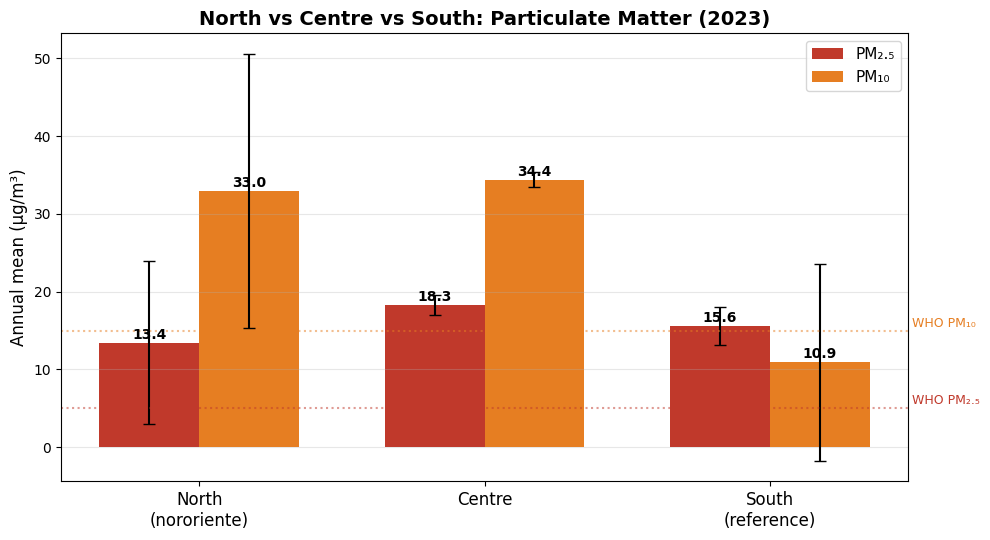

In [91]:
# ---------------------------------------------------------------------------
# North vs Centre vs South: PM2.5 and PM10
# ---------------------------------------------------------------------------
# Station lists come from src.stations.STATIONS_BY_ZONE
norte_names  = STATIONS_BY_ZONE["norte"]
centro_names = STATIONS_BY_ZONE["centro"]
sur_names    = STATIONS_BY_ZONE["sur"]

# zone_stats imported from src.stations

norte  = zone_stats(annual_stats, norte_names)
centro = zone_stats(annual_stats, centro_names)
sur    = zone_stats(annual_stats, sur_names)

zones = {"Norte (nororiente)": norte, "Centro": centro, "Sur (reference)": sur}
for zone_name, zdf in zones.items():
    print("=" * 60)
    nstations = {"Norte (nororiente)": len(norte_names), "Centro": len(centro_names), "Sur (reference)": len(sur_names)}[zone_name]
    print(f"  {zone_name} \u2014 {nstations} stations")
    print("=" * 60)
    for pol in ["PM2.5", "PM10"]:
        if pol in zdf.index:
            r = zdf.loc[pol]
            print(f"  {pol:6s}: {r['mean']:.1f} \u00b1 {r['std']:.1f} \u03bcg/m\u00b3  "
                  f"(range: {r['min']:.1f}\u2013{r['max']:.1f})")
        else:
            print(f"  {pol:6s}: no data")

print()
print("=" * 60)
print("  Gap (North vs Sur)")
print("=" * 60)
for pol in ["PM2.5", "PM10"]:
    if pol in norte.index and pol in sur.index:
        gap = norte.loc[pol, "mean"] - sur.loc[pol, "mean"]
        ratio = norte.loc[pol, "mean"] / sur.loc[pol, "mean"]
        print(f"  {pol:6s}: {gap:.1f} \u03bcg/m\u00b3 ({ratio:.1f}\u00d7 "
              f"higher in the north)")

# Bar chart comparison \u2014 3 zones
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(3)
width = 0.35

def get_val(zdf, pol):
    return zdf.loc[pol, "mean"] if pol in zdf.index else 0

def get_std(zdf, pol):
    return zdf.loc[pol, "std"] if pol in zdf.index else 0

pm25_vals = [get_val(norte, "PM2.5"), get_val(centro, "PM2.5"), get_val(sur, "PM2.5")]
pm10_vals = [get_val(norte, "PM10"), get_val(centro, "PM10"), get_val(sur, "PM10")]
pm25_err = [get_std(norte, "PM2.5"), get_std(centro, "PM2.5"), get_std(sur, "PM2.5")]
pm10_err = [get_std(norte, "PM10"), get_std(centro, "PM10"), get_std(sur, "PM10")]

bars1 = ax.bar(x - width/2, pm25_vals, width, yerr=pm25_err,
               label="PM\u2082.\u2085", color="#c0392b", capsize=4)
bars2 = ax.bar(x + width/2, pm10_vals, width, yerr=pm10_err,
               label="PM\u2081\u2080", color="#e67e22", capsize=4)

# WHO lines
ax.axhline(5, color="#c0392b", linestyle=":", alpha=0.5, linewidth=1.5)
ax.text(2.5, 5.5, "WHO PM\u2082.\u2085", fontsize=9, color="#c0392b")
ax.axhline(15, color="#e67e22", linestyle=":", alpha=0.5, linewidth=1.5)
ax.text(2.5, 15.5, "WHO PM\u2081\u2080", fontsize=9, color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(["North\n(nororiente)", "Centre", "South\n(reference)"], fontsize=12)
ax.set_ylabel("Annual mean (\u03bcg/m\u00b3)", fontsize=12)
ax.set_title("North vs Centre vs South: Particulate Matter (2023)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", fontsize=10, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## Ranking the burden: who has it worst across all variables?

Satellites and ground monitors tell complementary stories:
- **NO2** (from Sentinel-5P, Notebook 01 a 03) shows traffic and industrial emissions.
- **PM2.5 and PM10** (from SINAICA, this notebook) shows what people actually breathe at street level.
- **NDVI** (from Landsat, Notebook 02) shows vegetation — nature\u2019s air filter.

A regression scatter is misleading. Instead, we **rank** each station across the three variables and ask: *does the same neighborhood consistently rank worst?*

> **How ranking works:** For each variable, the station with the worst environmental condition gets rank #1, the second-worst gets rank #2, etc. "Worst" means highest pollution (PM10, PM2.5, NO2) or lowest vegetation (NDVI). The **burden score** is the average rank across all three variables — closer to 1 = more burden.


In [92]:
# ---------------------------------------------------------------------------
# NDVI sampling at station locations + environmental ranking table
# ---------------------------------------------------------------------------
print("Sampling NDVI at station locations from Landsat...")

# Load summer NDVI composite (same as Notebook 02)
aoi_zmvm = get_zmvm_municipalities_aoi()
ndvi_summer = load_ndvi_composite(
    aoi_zmvm, start_date="2025-06-01", end_date="2025-09-01", cloud_max=20.0,
)

# Create point features for each station
points = []
for name, meta in STATIONS_META.items():
    pt = ee.Geometry.Point([meta["lng"], meta["lat"]])
    feat = ee.Feature(pt, {"name": name})
    points.append(feat)
stations_fc = ee.FeatureCollection(points)

# Sample NDVI at station points
sampled = ndvi_summer.sampleRegions(
    collection=stations_fc, scale=30, geometries=False,
)
ndvi_data = sampled.getInfo()

# Parse into DataFrame
ndvi_records = []
for feat in ndvi_data["features"]:
    props = feat["properties"]
    ndvi_records.append({
        "station_name": props.get("name", "Unknown"),
        "ndvi": props.get("NDVI", None),
    })
ndvi_df = pd.DataFrame(ndvi_records)
print(f"✅ Sampled {len(ndvi_df)} stations\n")

# ---------------------------------------------------------------------------
# Build ranking table — handle missing PM2.5 data (SINAICA returns zeros
# for stations without PM2.5 monitors, e.g. Ecatepec, Naucalpan)
# ---------------------------------------------------------------------------
records = []
for name, meta in STATIONS_META.items():
    row_stats = annual_stats[annual_stats["station_name"] == name]
    
    no2_row = row_stats[row_stats["pollutant"] == "NO2"]
    no2 = no2_row["annual_mean"].values[0] if len(no2_row) else float("nan")
    
    pm25_row = row_stats[row_stats["pollutant"] == "PM2.5"]
    pm25_val = pm25_row["annual_mean"].values[0] if len(pm25_row) else 0.0
    # If annual_mean is 0 and count_valid > 0, it's a placeholder, not real data
    pm25_count = pm25_row["count_valid"].values[0] if len(pm25_row) else 0
    pm25_ok = pm25_val > 0 or pm25_count == 0
    
    ndvi_val = ndvi_df[ndvi_df["station_name"] == name]["ndvi"].values
    ndvi_val = ndvi_val[0] if len(ndvi_val) and ndvi_val[0] is not None else float("nan")
    
    records.append({
        "station": name,
        "municipio": meta["municipio"],
        "zone": meta["zone"],
        "PM2.5": round(pm25_val, 1) if pm25_ok else None,
        "pm25_ok": pm25_ok,
        "NO2_ppb": round(no2 * 1000, 1),
        "NDVI": round(ndvi_val, 4),
    })

rank_df = pd.DataFrame(records)

# Compute ranks
# PM2.5: only rank stations with real data (they get ranks 1..N, best gets highest rank)
valid_pm25 = rank_df[rank_df["pm25_ok"]].copy()
if len(valid_pm25) > 1:
    valid_pm25["r_base"] = valid_pm25["PM2.5"].rank(ascending=False)
    rank_df["r_PM2.5"] = None
    rank_df.loc[valid_pm25.index, "r_PM2.5"] = valid_pm25["r_base"].values

# NO2: higher = worse = rank 1
rank_df["r_NO2"] = rank_df["NO2_ppb"].rank(ascending=False).astype(int)

# NDVI: lower = worse = rank 1 (less vegetation = more burden)
rank_df["r_NDVI"] = rank_df["NDVI"].rank(ascending=True).astype(int)

# Burden = average of available ranks (handle missing PM2.5 gracefully)
def calc_burden(row):
    ranks = []
    if pd.notna(row.get("r_PM2.5")):
        ranks.append(row["r_PM2.5"])
    ranks.append(row["r_NO2"])
    ranks.append(row["r_NDVI"])
    return round(sum(ranks) / len(ranks), 2)

rank_df["burden"] = rank_df.apply(calc_burden, axis=1)

# Sort by burden ascending (1 = most burdened)
rank_df = rank_df.sort_values("burden").reset_index(drop=True)
rank_df["overall"] = range(1, len(rank_df) + 1)

# Display table
from IPython.display import display, HTML

# Prepare display columns
display_data = rank_df[["overall", "station", "zone", "PM2.5", "NO2_ppb", "NDVI", "burden"]].copy()

# Build the display
html_rows = []
html_rows.append(f'''<table style="border-collapse: collapse; font-size: 13px;">
<thead>
<tr style="border-bottom: 2px solid #2c3e50;">
  <th style="padding: 8px; text-align: center;">#</th>
  <th style="padding: 8px; text-align: left;">Station</th>
  <th style="padding: 8px; text-align: center;">Zone</th>
  <th style="padding: 8px; text-align: center;" colspan="2">PM₂.₅ (µg/m³)</th>
  <th style="padding: 8px; text-align: center;" colspan="2">NO₂ (ppb)</th>
  <th style="padding: 8px; text-align: center;" colspan="2">NDVI</th>
  <th style="padding: 8px; text-align: center;">Burden</th>
</tr>
</thead>
<tbody>''')

for _, row in rank_df.iterrows():
    zone_class = row["zone"]
    row_color = "#ffeeee" if zone_class == "norte" else "#fff8e1" if zone_class == "centro" else "#eeffee"
    
    pm25_display = f"{row['PM2.5']:.1f}" if pd.notna(row["PM2.5"]) else "<span style='color:#999;'>N/A</span>"
    pm25_rank = f"#{int(row['r_PM2.5'])}" if pd.notna(row.get("r_PM2.5")) else "<span style='color:#999;'>—</span>"
    pm25_note = " ⚠ no data" if pd.isna(row["PM2.5"]) else ""
    
    # Color ranks: 1-3 red, 4-5 yellow, 6-8 green
    def rank_color(r, better_high=True):
        if pd.isna(r):
            return "#cccccc"
        # Dynamic colormap: worst = red, middle = yellow, best = green
        # Works for any number of stations
        n_stations = len(rank_df)
        if better_high:
            # Higher rank (value) = better = green
            pos = int(r) - 1  # 0-indexed
            ratio = pos / max(n_stations - 1, 1)  # 0=worst, 1=best
        else:
            # Lower rank (value) = better = green
            pos = n_stations - int(r)
            ratio = pos / max(n_stations - 1, 1)
        if ratio < 0.33:
            return "#e74c3c"
        elif ratio < 0.66:
            return "#f1c40f"
        else:
            return "#1a9641"
    
    r_pm25_c = rank_color(row.get("r_PM2.5"), better_high=True)
    r_no2_c  = rank_color(row["r_NO2"], better_high=True)
    r_ndvi_c = rank_color(row["r_NDVI"], better_high=True)
    n_stn = len(rank_df)
    r_burden = rank_color(n_stn - row["burden"] + 1, better_high=True) if row["burden"] <= n_stn else "#cccccc"
    
    html_rows.append(f'''<tr style="background: {row_color}; border-bottom: 1px solid #ddd;">
  <td style="padding: 6px; text-align: center; font-weight: bold;">#{row['overall']}</td>
  <td style="padding: 6px; text-align: left;"><b>{row['station']}</b>{pm25_note}</td>
  <td style="padding: 6px; text-align: center;">{'Norte' if row['zone'] == 'norte' else 'Centro' if row['zone'] == 'centro' else 'Sur'}</td>
  <td style="padding: 6px; text-align: right;">{pm25_display}</td>
  <td style="padding: 6px; text-align: center; background: {r_pm25_c}; color: white; font-weight: bold; border-radius: 4px;">{pm25_rank}</td>
  <td style="padding: 6px; text-align: right;">{row['NO2_ppb']:.1f}</td>
  <td style="padding: 6px; text-align: center; background: {r_no2_c}; color: white; font-weight: bold; border-radius: 4px;">#{int(row['r_NO2'])}</td>
  <td style="padding: 6px; text-align: right;">{row['NDVI']:.4f}</td>
  <td style="padding: 6px; text-align: center; background: {r_ndvi_c}; color: white; font-weight: bold; border-radius: 4px;">#{int(row['r_NDVI'])}</td>
  <td style="padding: 6px; text-align: center; background: {r_burden}; color: white; font-weight: bold; border-radius: 4px;">{row['burden']:.2f}</td>
</tr>''')

html_rows.append('''</tbody></table>''')
html_rows.append('''<p style="font-size: 12px; color: #666; margin-top: 8px;">
Rank: <span style="background: #e74c3c; color: white; padding: 2px 6px; border-radius: 3px;">1 = worst</span>
→
<span style="background: #1a9641; color: white; padding: 2px 6px; border-radius: 3px;">N = best</span>
Burden = average rank across available variables. Stations with missing PM₂.₅ data (marked ⚠) are ranked on NO₂ + NDVI only.
</p>''')

display(HTML(''.join(html_rows)))

print("=" * 60)
print("  See table above for the full environmental burden ranking.")
print("=" * 60)




Sampling NDVI at station locations from Landsat...
✅ Sampled 13 stations



  See table above for the full environmental burden ranking.


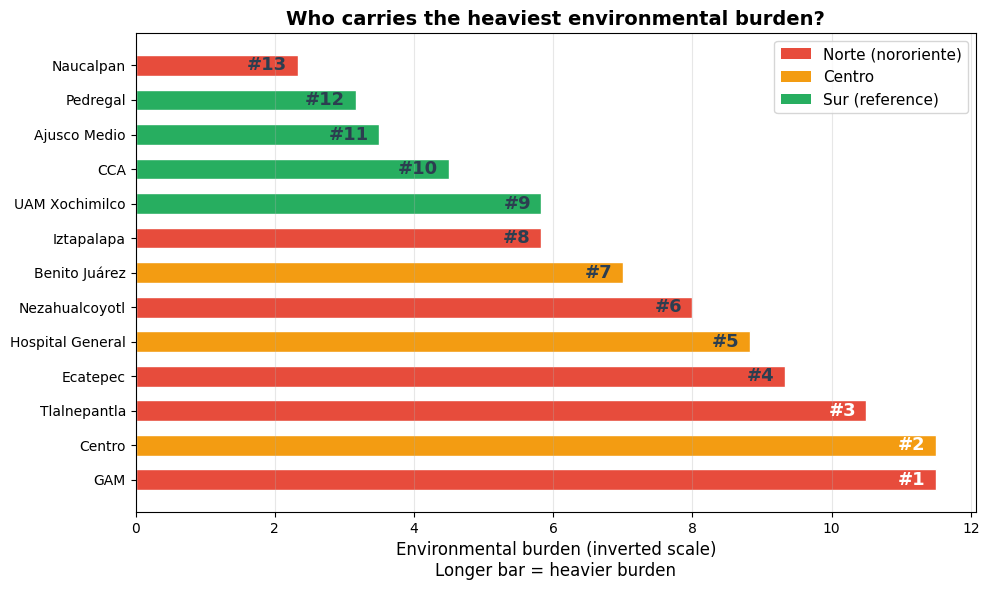

Note: Burden = average of PM₂.₅, NO₂, and NDVI ranks. The chart inverts the scale so longer = more burdened.
A station that is worst in all three would have the longest bar.


In [93]:
# ---------------------------------------------------------------------------
# Burden rank visualization
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Most burdened at the top
plot_df = rank_df.sort_values("burden", ascending=True).copy()

# INVERT the burden scale so the most burdened station has the longest bar.
# burden=1 (worst) -> display=13 (long bar), burden=13 (best) -> display=1 (short bar)
max_b = plot_df["burden"].max()
min_b = plot_df["burden"].min()
plot_df["burden_display"] = max_b + min_b - plot_df["burden"]

names   = plot_df["station"].tolist()
display = plot_df["burden_display"].tolist()
overall = plot_df["overall"].tolist()
zones   = plot_df["zone"].tolist()
colors  = plot_utils.zone_bar_colors(zones)

bars = ax.barh(names, display, color=colors, edgecolor="white", height=0.6)

# Rank labels inside bars
for bar, rank_val in zip(bars, overall):
    ax.text(
        bar.get_width() - 0.15, bar.get_y() + bar.get_height() / 2,
        f"#{rank_val}", va="center", ha="right",
        fontsize=13, fontweight="bold",
        color="white" if rank_val <= 3 else "#2c3e50",
    )

ax.set_xlabel("Environmental burden (inverted scale)\nLonger bar = heavier burden",
              fontsize=12)
ax.set_title("Who carries the heaviest environmental burden?",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# Legend
ax.legend(handles=plot_utils.create_zone_legend(loc="upper right"), loc="upper right", fontsize=11)

plt.tight_layout()
plt.show()

print("Note: Burden = average of PM\u2082.\u2085, NO\u2082, and NDVI ranks. "
      "The chart inverts the scale so longer = more burdened.\n"
      "A station that is worst in all three would have the longest bar.")



## The human connection

PM₂.₅ doesn’t just make you cough. It passes through lung tissue into the **bloodstream**. It’s linked to heart attacks, strokes, and low birth weight. The WHO estimates that air pollution kills **7 million people per year globally**.

In Ecatepec and Tlalnepantla, annual PM₂.₅ levels routinely exceed WHO guidelines by **3–5×**. That’s not just “bad air” — that’s a **public health emergency measured in micrograms per cubic meter**.

<div style="background: #fff3cd; border-left: 6px solid #ffc107; padding: 16px; border-radius: 6px; margin: 16px 0;">
<h3>🔍 Key finding</h3>
<p style="font-size: 15px;">
<b>Ground monitors confirm what satellites suggested:</b> the northern periphery breathes the worst air. PM₂.₅ levels in the nororiente are substantially higher than in southern reference areas. The same neighborhoods that are hottest (Notebook 01), have the fewest trees (Notebook 02), and the highest NO₂ (Notebook 03) also suffer the most particulate pollution.
</p>
<p style="font-size: 14px;"><i>Four notebooks, four variables, one pattern.</i></p>
</div>

## What we know, and what we don’t

✅ **Confirmed:**
- PM₂.₅ and PM₁₀ are significantly higher in the northern municipalities
- The pattern matches LST, NDVI, and NO₂: environmental burdens concentrate geographically
- All 8 stations exceed WHO safe limits for annual mean PM₂.₅ (5 μg/m³) and PM₁₀ (15 μg/m³)
- NO₂ and PM₂.₅ correlate strongly — the same combustion sources produce both

❓ **Still open questions:**
- Are these polluted, hot, treeless neighborhoods also the **poorest**? → Notebook 06: Marginalization
- Does breathing this particulate matter make people **sick**? → Notebook 07: Respiratory health
- Do residents themselves **perceive** this? → Notebook 08: Perception survey

📍 **The final synthesis — and what we should do about it — will come in Notebook 09.**


---
👉 **Next notebook:** *The Poverty-Pollution Connection — Marginalization and Environmental Justice*